In [1]:
import os
import pandas as pd
import numpy as np
import pydicom
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import cv2
import glob

In [2]:
!pip install comet_ml ultralytics
!pip install ultralytics comet_ml torch torchvision
!pip install -U ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 709.9/709.9 kB 14.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 896.9/896.9 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.8/981.8 kB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 83.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 3.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.4/214.4 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 52.0 MB/s eta 0:00:0000:01
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.7
    Uninstalling widgetsnbextension-3.6.7:
      Successfully uninstalled widgetsnbextension-3.6.7
  Attempting uninstall: jupyterlab-widgets
    Found existing installation: jupyterlab-widgets 3.0.9
    Uninstalling jupyterlab-widgets-3.0.9:
      Successfully uninstalled jupyterlab-widgets-3.0.9
  Attempting unins

In [3]:
!unzip -q /kaggle/input/lsdc-gen-yolo-data-ss/data_fold0.zip

In [4]:
ls

data_fold0/


In [5]:
IMG_DIR = "/kaggle/input/rsna-2024-lumbar-spine-degenerative-classification/train_images"

In [6]:
FOLD = 0
OD_INPUT_SIZE = 384
STD_BOX_SIZE = 20
BATCH_SIZE = 64
EPOCHS = 50

SAMPLE = None
CONDITIONS = ['Left Subarticular Stenosis', 'Right Subarticular Stenosis']
SEVERITIES = ['Normal/Mild', 'Moderate', 'Severe']
LEVELS = ['l1_l2', 'l2_l3', 'l3_l4', 'l4_l5', 'l5_s1']

DATA_DIR = f'data_fold{FOLD}'



In [7]:
# rm -rf val_fold0

In [8]:
train_val_df = pd.read_csv('/kaggle/input/rsna-2024-lumbar-spine-degenerative-classification/train.csv')
train_xy = pd.read_csv('/kaggle/input/rsna-2024-lumbar-spine-degenerative-classification/train_label_coordinates.csv')
train_des = pd.read_csv('/kaggle/input/rsna-2024-lumbar-spine-degenerative-classification/train_series_descriptions.csv')

In [9]:
if SAMPLE:
    train_val_df = train_val_df.sample(SAMPLE, random_state=2698)

In [10]:
fold_df = pd.read_csv('/kaggle/input/lsdc-fold-split/5folds.csv')

In [11]:
train_xy.head(3)

,study_id,series_id,instance_number,condition,level,x,y
0,4003253,702807833,8,Spinal Canal Stenosis,L1/L2,322.831858,227.964602
1,4003253,702807833,8,Spinal Canal Stenosis,L2/L3,320.571429,295.714286
2,4003253,702807833,8,Spinal Canal Stenosis,L3/L4,323.030303,371.818182


In [12]:
def get_level(text):
    for lev in ['l1_l2', 'l2_l3', 'l3_l4', 'l4_l5', 'l5_s1']:
        if lev in text:
            split = lev.split('_')
            split[0] = split[0].capitalize()
            split[1] = split[1].capitalize()
            return '/'.join(split)
    raise ValueError('Level not found '+ lev)
    
def get_condition(text):
    split = text.split('_')
    for i in range(len(split)):
        split[i] = split[i].capitalize()
    split = split[:-2]
    return ' '.join(split)
#     raise ValueError('Condition not found '+ lev)

In [13]:
train_xy['condition'].unique()

array(['Spinal Canal Stenosis', 'Right Neural Foraminal Narrowing',
       'Left Neural Foraminal Narrowing', 'Left Subarticular Stenosis',
       'Right Subarticular Stenosis'], dtype=object)

In [14]:
# train_df = train_df.dropna()

In [15]:
label_df = {'study_id':[], 'condition': [], 'level':[], 'label':[]}

for i, row in train_val_df.iterrows():
    study_id = row['study_id']
    for k, label in row.iloc[1:].to_dict().items():
        level = get_level(k)
        condition = get_condition(k)
        label_df['study_id'].append(study_id)
        label_df['condition'].append(condition)
        label_df['level'].append(level)
        label_df['label'].append(label)
#         break
#     break

label_df = pd.DataFrame(label_df)
label_df = label_df.merge(fold_df, on='study_id')

In [16]:
train_xy = train_xy.merge(train_des, how='inner', on=['study_id', 'series_id'])
label_df = label_df.merge(train_xy, how='inner', on=['study_id', 'condition', 'level'])

In [17]:
def query_train_xy_row(study_id, series_id=None, instance_num=None):
    if series_id is not None and instance_num is not None:
        return label_df[(label_df.study_id==study_id) & (label_df.series_id==series_id) &
            (label_df.instance_number==instance_num)]
    elif series_id is None and instance_num is None:
        return label_df[(label_df.study_id==study_id)]
    else:
        return label_df[(train_xy.study_id==study_id) & (label_df.series_id==series_id)]

In [18]:
def read_dcm(src_path):
    dicom_data = pydicom.dcmread(src_path)
    image = dicom_data.pixel_array
    image = (image - image.min()) / (image.max() - image.min() +1e-6) * 255
    image = np.stack([image]*3, axis=-1).astype('uint8')
    return image

def get_accronym(text):
    split = text.split(' ')
    return ''.join([x[0] for x in split])

In [19]:
# study_id = 4003253 
# series_id = 2448190387
# instance_num = 28

ex = label_df.sample(1).iloc[0]
study_id = ex.study_id
series_id = ex.series_id
instance_num = ex.instance_number

WIDTH = 10

path = os.path.join(IMG_DIR, str(study_id), str(series_id), f'{instance_num}.dcm')

In [20]:
img = read_dcm(path)

tmp_df = query_train_xy_row(study_id, series_id, instance_num)
for i, row in tmp_df.iterrows():
    lbl = f"{get_accronym(row['condition'])}_{row['level']}"
    x, y = row['x'], row['y']
    x1 = int(x - WIDTH)
    x2 = int(x + WIDTH)
    y1 = int(y - WIDTH)
    y2 = int(y + WIDTH)
    color = None
    if row['label'] == 'Normal/Mild':
        color =  (0, 255, 0)
    elif row['label'] == 'Moderate':
        color = (255,255,0) 
    elif row['label'] == 'Severe':
        color = (255,0,0)
        
    fontFace = cv2.FONT_HERSHEY_SIMPLEX
    fontScale = 0.5
    thickness = 1
    cv2.rectangle(img, (x1,y1), (x2,y2), color, 2)
    cv2.putText(img, lbl, (x1,y1), fontFace, fontScale, color, thickness, cv2.LINE_AA)

tmp_df

,study_id,condition,level,label,fold,series_id,instance_number,x,y,series_description
23926,2151509334,Left Subarticular Stenosis,L2/L3,Normal/Mild,1,3335666456,8,208.430357,201.600000,Axial T2
23931,2151509334,Right Subarticular Stenosis,L2/L3,Normal/Mild,1,3335666456,8,168.552212,203.044248,Axial T2


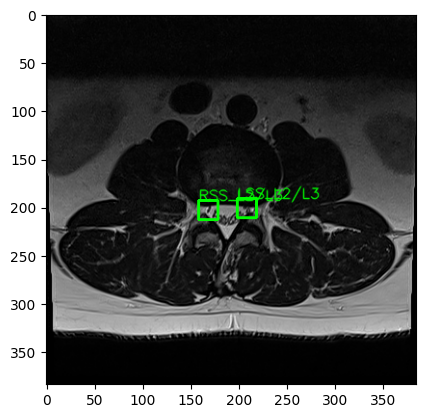

In [21]:
plt.imshow(img)
plt.show()

In [22]:
# label_df[['study_id', 'series_id']].drop_duplicates()

In [23]:
def read_dcm(src_path):
    dicom_data = pydicom.dcmread(src_path)
    image = dicom_data.pixel_array
    image = (image - image.min()) / (image.max() - image.min() +1e-6) * 255
    image = np.stack([image]*3, axis=-1).astype('uint8')
    return image

In [24]:
filtered_df = label_df[label_df.condition.map(lambda x: x in CONDITIONS)]

In [25]:
label2id = {}
id2label = {}
i = 0
for cond in CONDITIONS:
    for level in LEVELS:
        for severity in SEVERITIES:
            cls_ = f"{cond.lower().replace(' ', '_')}_{level}_{severity.lower()}"
            label2id[cls_] = i
            id2label[i] = cls_
            i+=1

In [26]:
id2label

{0: 'left_subarticular_stenosis_l1_l2_normal/mild',
 1: 'left_subarticular_stenosis_l1_l2_moderate',
 2: 'left_subarticular_stenosis_l1_l2_severe',
 3: 'left_subarticular_stenosis_l2_l3_normal/mild',
 4: 'left_subarticular_stenosis_l2_l3_moderate',
 5: 'left_subarticular_stenosis_l2_l3_severe',
 6: 'left_subarticular_stenosis_l3_l4_normal/mild',
 7: 'left_subarticular_stenosis_l3_l4_moderate',
 8: 'left_subarticular_stenosis_l3_l4_severe',
 9: 'left_subarticular_stenosis_l4_l5_normal/mild',
 10: 'left_subarticular_stenosis_l4_l5_moderate',
 11: 'left_subarticular_stenosis_l4_l5_severe',
 12: 'left_subarticular_stenosis_l5_s1_normal/mild',
 13: 'left_subarticular_stenosis_l5_s1_moderate',
 14: 'left_subarticular_stenosis_l5_s1_severe',
 15: 'right_subarticular_stenosis_l1_l2_normal/mild',
 16: 'right_subarticular_stenosis_l1_l2_moderate',
 17: 'right_subarticular_stenosis_l1_l2_severe',
 18: 'right_subarticular_stenosis_l2_l3_normal/mild',
 19: 'right_subarticular_stenosis_l2_l3_moderat

In [27]:
train_df = filtered_df[filtered_df.fold != FOLD]
val_df = filtered_df[filtered_df.fold == FOLD]

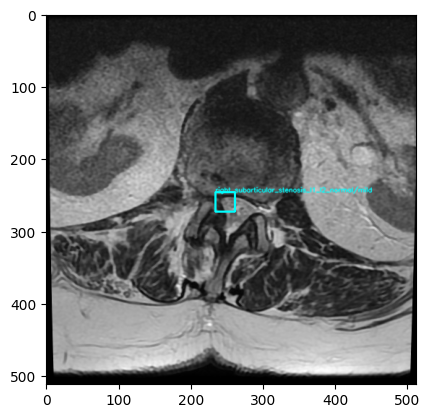

In [28]:
# # test generated annotations

_IM_DIR = f'{DATA_DIR}/images/train'
_ANN_DIR = f'{DATA_DIR}/labels/train'
name = np.random.choice(os.listdir(_IM_DIR))[:-4]

im = plt.imread(os.path.join(_IM_DIR, name+'.jpg')).copy()
H,W = im.shape[:2]
anns = np.loadtxt(os.path.join(_ANN_DIR, name+'.txt')).reshape(-1, 5)

for _cls, x,y,w,h in anns.tolist():
    x *= W
    y *= H
    w *= W
    h *= H
    x1 = int(x-w/2)
    x2 = int(x+w/2)
    y1 = int(y-h/2)
    y2 = int(y+h/2)
    label = id2label[_cls]
    
#     if _cls == 0:
#         c = (255,0,0)
#     elif _cls == 1:
#         c = (0,255,0)
#     else:
#         c = (255,255,0)
    c = (0,255,255)

    im = cv2.rectangle(im, (x1,y1), (x2,y2), c, 2)
    cv2.putText(im, label, (x1,y1), fontFace, 0.3, c, 1, cv2.LINE_AA)


plt.imshow(im)

In [29]:
# ls data_fold0/labels/val

In [30]:
# os.path.join(_ANN_DIR, name+'.txt')

In [31]:
# cat 'train_fold0/labels/404602713_1230697721_12.txt'

In [32]:
for k, v in id2label.items():
    print(f'{k}: {v}')

0: left_subarticular_stenosis_l1_l2_normal/mild
1: left_subarticular_stenosis_l1_l2_moderate
2: left_subarticular_stenosis_l1_l2_severe
3: left_subarticular_stenosis_l2_l3_normal/mild
4: left_subarticular_stenosis_l2_l3_moderate
5: left_subarticular_stenosis_l2_l3_severe
6: left_subarticular_stenosis_l3_l4_normal/mild
7: left_subarticular_stenosis_l3_l4_moderate
8: left_subarticular_stenosis_l3_l4_severe
9: left_subarticular_stenosis_l4_l5_normal/mild
10: left_subarticular_stenosis_l4_l5_moderate
11: left_subarticular_stenosis_l4_l5_severe
12: left_subarticular_stenosis_l5_s1_normal/mild
13: left_subarticular_stenosis_l5_s1_moderate
14: left_subarticular_stenosis_l5_s1_severe
15: right_subarticular_stenosis_l1_l2_normal/mild
16: right_subarticular_stenosis_l1_l2_moderate
17: right_subarticular_stenosis_l1_l2_severe
18: right_subarticular_stenosis_l2_l3_normal/mild
19: right_subarticular_stenosis_l2_l3_moderate
20: right_subarticular_stenosis_l2_l3_severe
21: right_subarticular_stenosis

In [33]:
ls

data_fold0/


In [34]:
%%writefile yolo_scs.yaml
path: /kaggle/working/data_fold0 # dataset root dir
train: images/train  
val: images/val 
test: images/val 

# Classes
names:
    0: left_subarticular_stenosis_l1_l2_normal/mild
    1: left_subarticular_stenosis_l1_l2_moderate
    2: left_subarticular_stenosis_l1_l2_severe
    3: left_subarticular_stenosis_l2_l3_normal/mild
    4: left_subarticular_stenosis_l2_l3_moderate
    5: left_subarticular_stenosis_l2_l3_severe
    6: left_subarticular_stenosis_l3_l4_normal/mild
    7: left_subarticular_stenosis_l3_l4_moderate
    8: left_subarticular_stenosis_l3_l4_severe
    9: left_subarticular_stenosis_l4_l5_normal/mild
    10: left_subarticular_stenosis_l4_l5_moderate
    11: left_subarticular_stenosis_l4_l5_severe
    12: left_subarticular_stenosis_l5_s1_normal/mild
    13: left_subarticular_stenosis_l5_s1_moderate
    14: left_subarticular_stenosis_l5_s1_severe
    15: right_subarticular_stenosis_l1_l2_normal/mild
    16: right_subarticular_stenosis_l1_l2_moderate
    17: right_subarticular_stenosis_l1_l2_severe
    18: right_subarticular_stenosis_l2_l3_normal/mild
    19: right_subarticular_stenosis_l2_l3_moderate
    20: right_subarticular_stenosis_l2_l3_severe
    21: right_subarticular_stenosis_l3_l4_normal/mild
    22: right_subarticular_stenosis_l3_l4_moderate
    23: right_subarticular_stenosis_l3_l4_severe
    24: right_subarticular_stenosis_l4_l5_normal/mild
    25: right_subarticular_stenosis_l4_l5_moderate
    26: right_subarticular_stenosis_l4_l5_severe
    27: right_subarticular_stenosis_l5_s1_normal/mild
    28: right_subarticular_stenosis_l5_s1_moderate
    29: right_subarticular_stenosis_l5_s1_severe
  

Writing yolo_scs.yaml


In [35]:
from comet_ml import Experiment
from ultralytics import YOLO
from comet_ml import Experiment
from ultralytics import YOLO

experiment = Experiment(
    api_key="TEvwjfifJIYbB1woGPKGnzP0h",
    project_name="lsdc-sip",
    workspace="sentientbee",
)

config = {
    "model": "yolov8s.pt",
    "data": "/kaggle/working/yolo_scs.yaml",
    "epochs": 40,
    "batch_size": 16,
    "img_size": 640,
}

os.environ['COMET_API_KEY'] = 'TEvwjfifJIYbB1woGPKGnzP0h'


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/sentientbee/lsdc-sip/a521b93ccf4a448b99d4b3d7dd5f2540



In [36]:


# Log parameters
experiment.log_parameters(config)

# Initialize and train the model
model = YOLO(config['model'])
results = model.train(
    data=config['data'],
    epochs=config['epochs'],
    batch=config['batch_size'],
    imgsz=config['img_size'],
    device="0,1"
)

# Log training metrics
metrics = {
    "precision": results.metrics.get('precision', 0),
    "recall": results.metrics.get('recall', 0),
    "mAP_50": results.metrics.get('mAP50', 0),
    "mAP_95": results.metrics.get('mAP50-95', 0),
}
experiment.log_metrics(metrics)

# Save the model and upload it to Comet
model_path = "runs/train/exp/weights/best.pt"
experiment.log_model("yolo-model", model_path)

# Close the experiment
experiment.end()

COMET INFO: Couldn't find a Git repository in '/kaggle/working' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.


100%|██████████| 21.5M/21.5M [00:00<00:00, 172MB/s]


Ultralytics 8.3.39 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla T4, 15095MiB)
                                                 CUDA:1 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/kaggle/working/yolo_scs.yaml, epochs=40, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0,1, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_

100%|██████████| 755k/755k [00:00<00:00, 16.2MB/s]
2024-11-28 23:47:12,579	INFO util.py:124 -- Outdated packages:
  ipywidgets==7.7.1 found, needs ipywidgets>=8
Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2024-11-28 23:47:13,361	INFO util.py:124 -- Outdated packages:
  ipywidgets==7.7.1 found, needs ipywidgets>=8
Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Overriding model.yaml nc=80 with nc=30

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytic

...

                   all       2726       3856      0.404      0.557      0.433      0.219

40 epochs completed in 1.630 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 22.5MB
Optimizer stripped from runs/detect/train/weights/best.pt, 22.5MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.39 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla T4, 15095MiB)
                                                 CUDA:1 (Tesla T4, 15095MiB)
Model summary (fused): 168 layers, 11,137,194 parameters, 0 gradients, 28.5 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 171/171 [00:24<00:00,  6.94it/s]


                   all       2726       3856      0.412      0.581      0.438      0.221
left_subarticular_stenosis_l1_l2_normal/mild        349        349      0.603      0.868      0.621      0.304
left_subarticular_stenosis_l1_l2_moderate         15         15      0.303      0.467      0.323      0.182
left_subarticular_stenosis_l1_l2_severe          4          4      0.303       0.25      0.216      0.072
left_subarticular_stenosis_l2_l3_normal/mild        316        316      0.574      0.854      0.631      0.337
left_subarticular_stenosis_l2_l3_moderate         49         49      0.369       0.51      0.324       0.19
left_subarticular_stenosis_l2_l3_severe         12         12      0.271      0.333      0.252      0.141
left_subarticular_stenosis_l3_l4_normal/mild        254        254      0.568      0.843      0.632      0.343
left_subarticular_stenosis_l3_l4_moderate        100        100       0.39       0.64      0.414      0.247
left_subarticular_stenosis_l3_l4_severe   

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : prime_router_5225
COMET INFO:     url                   : https://www.comet.com/sentientbee/general/c3f70ddbad70449e8f4975f5cfb029a9
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     lr/pg0 [81]               : (2.4811500000000018e-05, 0.0006783286705370102)
COMET INFO:     lr/pg1 [81]               : (2.4811500000000018e-05, 0.0006783286705370102)
COMET INFO:     lr/pg2 [81]               : (2.4811500000000018e-05, 0.0006783286705370102)
COMET INFO:     metrics/mAP50(B) [82]     : (0.18547, 0.43795)
COMET INFO:     metrics/mAP50-95(B) [82]  : (0.08245, 0.22135)
COMET INFO:     metrics/precision(B) [82] : (0.26333, 0.47605)
COMET INFO:     me

AttributeError: 'NoneType' object has no attribute 'metrics'

In [ ]:
# # test generated annotations

_IM_DIR = f'{DATA_DIR}/images/val'
_ANN_DIR = f'{DATA_DIR}/labels/val'
name = np.random.choice(os.listdir(_IM_DIR))[:-4]

path = os.path.join(_IM_DIR, name+'.jpg')

im = plt.imread(path).copy()
H,W = im.shape[:2]
anns = np.loadtxt(os.path.join(_ANN_DIR, name+'.txt')).reshape(-1, 5)

for _cls, x,y,w,h in anns.tolist():
    x *= W
    y *= H
    w *= W
    h *= H
    x1 = int(x-w/2)
    x2 = int(x+w/2)
    y1 = int(y-h/2)
    y2 = int(y+h/2)
    label = id2label[_cls]
    print(label)
    
#     if _cls == 0:
#         c = (255,0,0)
#     elif _cls == 1:
#         c = (0,255,0)
#     else:
#         c = (255,255,0)
    c = (0,255,255)

    im = cv2.rectangle(im, (x1,y1), (x2,y2), c, 2)
    cv2.putText(im, label, (x1,y1), fontFace, 0.3, c, 1, cv2.LINE_AA)


plt.imshow(im)

In [ ]:
# Initialize YOLO Model
model = YOLO(glob.glob("lsdc_yolov8/*/weights/best.pt")[0])

# Add W&B callback for Ultralytics
# add_wandb_callback(model, enable_model_checkpointing=True)

# Perform prediction which automatically logs to a W&B Table
# with interactive overlays for bounding boxes, segmentation masks
out = model.predict([path], save=True, conf=0.2)

# Finish the W&B run
wandb.finish()

In [ ]:
im = plt.imread(glob.glob(f'{out[0].save_dir}/*.jpg')[0])
plt.imshow(im)